# Garbage Reports — Model Selection

This notebook answers one question: **which city-wide forecasting model should we use?** Reusable preparation/fitting logic lives in `src/citywide_forecasting.py`.

## 1. Imports

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.citywide_forecasting import (
    evaluate_log_divisors,
    evaluate_models,
    poisson_overdispersion,
    prepare_daily_data,
)

## 2. Configuration

This notebook uses a configuration-driven approach: choose the models and settings below, then rerun the model-comparison cells.

### Available values for `MODELS_TO_TEST`

| Value | Description |
|---|---|
| `"all"` | Test every baseline and every Negative Binomial model below |
| `"baselines"` | Test all five simple baseline methods |
| `"mean"` | Historical mean of daily reports |
| `"weekday_mean"` | Historical mean for the corresponding weekday |
| `"lag7"` | Actual report count from exactly 7 days earlier |
| `"rolling7"` | Average of the previous 7 actual days |
| `"same_weekday_4wk"` | Average of the same weekday over the previous 4 weeks |
| `"nb_base"` | Trend + weekday + month |
| `"nb_lag1"` | Trend + weekday + month + previous day's count |
| `"nb_recent3"` | Trend + weekday + month + average of previous 3 days |
| `"nb_recent3_lag7"` | Trend + weekday + month + recent 3-day average + lag 7 |
| `"nb_lag1_lag7"` | Trend + weekday + month + lag 1 + lag 7 |
| `"nb_4wk"` | Trend + weekday + month + previous 4 same-weekday average |
| `"nb_quadratic"` | Selected trend + its squared term + weekday + month |
| `"nb_recent3_lag7_no_weekday"` | Trend + month + recent 3-day average + lag 7; removes weekday |
| `"nb_recent3_lag7_no_weekday_no_trend"` | Month + recent 3-day average + lag 7; removes both weekday and trend |

Holiday terms are controlled separately with `HOLIDAY_MODE`, so they do not need separate model names.

### Trend settings

`TREND_MODE` controls the time-trend term used by the Negative Binomial models:

| Setting | Trend used |
|---|---|
| `"linear"` | `trend_years` |
| `"log"` | `log1p(trend_years / LOG_TREND_DIVISOR)` |
| `"none"` | No time trend |

When `TREND_MODE = "log"`, `LOG_TREND_DIVISOR` controls the curvature of the log trend.

The current selected value is:

`LOG_TREND_DIVISOR = 3`

### Holiday settings

| `HOLIDAY_MODE` | Meaning |
|---|---|
| `"without"` | Test NB models without the Greek holiday indicator |
| `"with"` | Test NB models with the Greek holiday indicator |
| `"both"` | Fit and compare both versions |

### Examples

Test only the two main NB candidates:

```python
MODELS_TO_TEST = [
    "nb_recent3",
    "nb_recent3_lag7",
]

The model-testing workflow stays configuration-driven. `TREND_MODE='log'` uses `log1p(trend_years / LOG_TREND_DIVISOR)`.

In [11]:
DATA_PATH = PROJECT_ROOT / "data" / "requests.csv"

ISSUE_TYPE = "garbage"
START_YEAR = 2020
END_YEAR = 2025

MODELS_TO_TEST = [
    "nb_recent3",
    "nb_recent3_lag7",
]
HOLIDAY_MODE = "with"        # "without", "with", or "both"
TREND_MODE = "log"           # "linear", "log", or "none"
LOG_TREND_DIVISOR = 4
TEST_YEARS = [2023, 2024, 2025]

# Optional historical search for log1p(trend_years / k).
RUN_DIVISOR_SEARCH = True
DIVISORS_TO_TEST = range(1, 31)
DIVISOR_MODEL = "nb_recent3_lag7"

# Optional prediction/residual plot from the OOS results.
PLOT_BASE_MODEL = "nb_recent3_lag7"
PLOT_HOLIDAY_VERSION = "with"
PLOT_YEAR = 2025
SMOOTHING_DAYS = 14

## 3. Prepare daily data

In [14]:
raw_df = pd.read_csv(DATA_PATH)

daily_df = prepare_daily_data(
    raw_df,
    issue_type=ISSUE_TYPE,
    start_year=START_YEAR,
    end_year=END_YEAR,
    log_divisor=LOG_TREND_DIVISOR,
)

print(f"Daily observations: {len(daily_df):,}")
print(
    f"Date range: {daily_df['reported'].min().date()} "
    f"-> {daily_df['reported'].max().date()}"
)
print(
    f"Trend: {TREND_MODE}"
    + (
        f" | log divisor: {LOG_TREND_DIVISOR}"
        if TREND_MODE == "log"
        else ""
    )
)

Daily observations: 2,191
Date range: 2020-01-02 -> 2025-12-31
Trend: log | log divisor: 4


## 4. Poisson overdispersion check

This is the compact justification for preferring Negative Binomial over ordinary Poisson.

In [4]:
dispersion = poisson_overdispersion(
    daily_df,
    end_year=2024,
    trend_mode=TREND_MODE,
)

display(dispersion.round(4).to_frame("value"))

,value
raw_mean,19.4272
raw_variance,168.9111
variance_mean_ratio,8.6946
pearson_dispersion,3.1930
deviance_per_df,3.4339
pearson_p_value,0.0000


## 5. Chronological model comparison

In [15]:
yearly_results, average_results, oos_predictions = evaluate_models(
    daily_df,
    models_to_test=MODELS_TO_TEST,
    holiday_mode=HOLIDAY_MODE,
    test_years=TEST_YEARS,
    trend_mode=TREND_MODE,
)

print("YEAR-BY-YEAR PERFORMANCE")
display(
    yearly_results[
        ["Test Year", "Model", "Holiday Version", "MAE", "RMSE", "Alpha", "N"]
    ].round(3)
)

print("\nAVERAGE PERFORMANCE")
display(average_results.round(3))

best = average_results.iloc[0]
print(f"\nBest average MAE: {best['Model']} -> {best['Mean_MAE']:.3f}")

YEAR-BY-YEAR PERFORMANCE


,Test Year,Model,Holiday Version,MAE,RMSE,Alpha,N
0,2023,nb_recent3 | with holidays,with,6.796,9.208,0.093,365
1,2023,nb_recent3_lag7 | with holidays,with,6.506,8.867,0.091,365
2,2024,nb_recent3 | with holidays,with,6.276,8.439,0.094,366
3,2024,nb_recent3_lag7 | with holidays,with,6.335,8.571,0.091,366
4,2025,nb_recent3 | with holidays,with,7.051,9.453,0.092,365
5,2025,nb_recent3_lag7 | with holidays,with,7.084,9.548,0.090,365



AVERAGE PERFORMANCE


,Model,Base Model,Holiday Version,Mean_MAE,Mean_RMSE,Mean_Alpha
0,nb_recent3_lag7 | with holidays,nb_recent3_lag7,with,6.642,8.995,0.091
1,nb_recent3 | with holidays,nb_recent3,with,6.708,9.033,0.093



Best average MAE: nb_recent3_lag7 | with holidays -> 6.642


## 6. Optional log-trend divisor search

Turn `RUN_DIVISOR_SEARCH=True` only when you intentionally want to compare integer values of `k`.

In [9]:
if RUN_DIVISOR_SEARCH:
    divisor_summary, divisor_yearly = evaluate_log_divisors(
        daily_df,
        DIVISORS_TO_TEST,
        model_name=DIVISOR_MODEL,
        test_years=TEST_YEARS,
        include_holidays=(HOLIDAY_MODE != "without"),
    )

    print("BEST LOG-TREND DIVISORS")
    display(divisor_summary.head(15).round(4))

    best_k = int(divisor_summary.iloc[0]["k"])
    print(f"\nBest historical integer k: {best_k}")
    print(f"Use: log1p(trend_years / {best_k})")

    print("\nBEST k — YEAR BY YEAR")
    display(divisor_yearly[divisor_yearly["k"] == best_k].round(4))
else:
    print("Divisor search skipped.")

BEST LOG-TREND DIVISORS


,k,Mean_MAE,Mean_RMSE,Mean_Alpha,MAE_rank,RMSE_rank,combined_rank
0,4,6.6416,8.9951,0.0907,1.0,1.0,2.0
1,3,6.6425,8.9965,0.0909,2.0,3.0,5.0
2,5,6.6427,8.9964,0.0906,3.0,2.0,5.0
3,6,6.6449,8.9989,0.0906,4.0,4.0,8.0
4,7,6.6473,9.0018,0.0905,5.0,5.0,10.0
5,2,6.6492,9.0048,0.0912,6.0,7.0,13.0
6,8,6.6500,9.0047,0.0905,7.0,6.0,13.0
7,9,6.6530,9.0076,0.0904,8.0,8.0,16.0
8,10,6.6559,9.0103,0.0904,9.0,9.0,18.0
9,11,6.6585,9.0128,0.0904,10.0,10.0,20.0



Best historical integer k: 4
Use: log1p(trend_years / 4)

BEST k — YEAR BY YEAR


,k,year,MAE,RMSE,alpha
9,4,2023,6.5063,8.8667,0.0908
10,4,2024,6.3349,8.5707,0.0912
11,4,2025,7.0835,9.5479,0.0902


## 7. OOS prediction and residual diagnostics

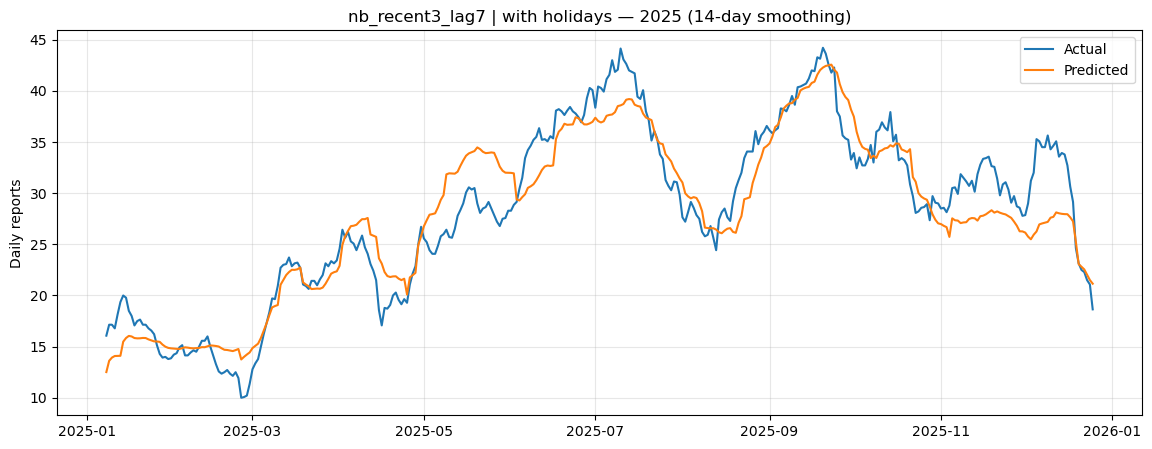

Mean residual: 0.303


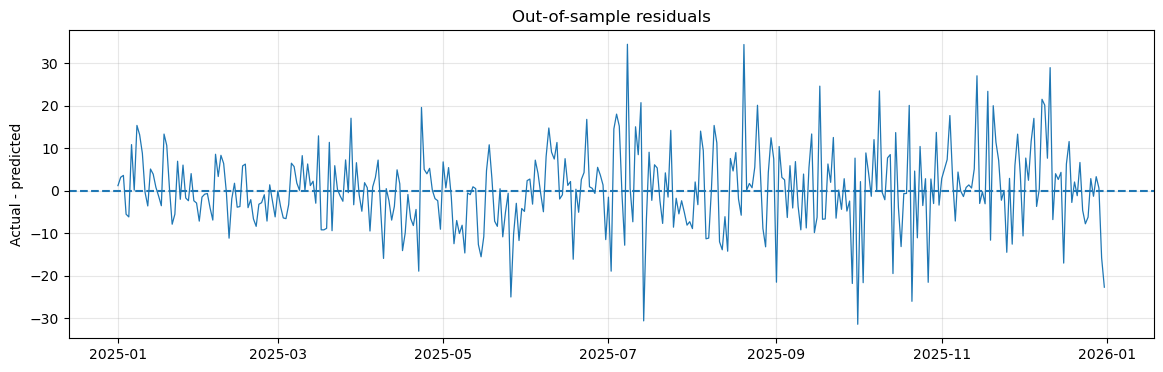

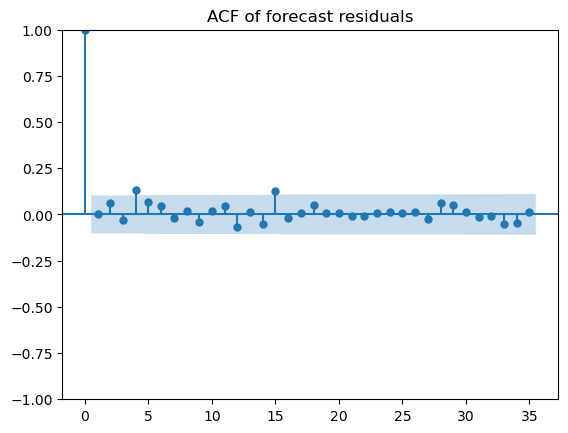

In [16]:
plot_model = (
    f"{PLOT_BASE_MODEL} | {PLOT_HOLIDAY_VERSION} holidays"
    if PLOT_BASE_MODEL.startswith("nb_")
    else PLOT_BASE_MODEL
)

plot_data = (
    oos_predictions[
        (oos_predictions["Model"] == plot_model)
        & (oos_predictions["Test Year"] == PLOT_YEAR)
    ]
    .sort_values("reported")
    .copy()
)

if plot_data.empty:
    print(
        f"No predictions for {plot_model!r} in {PLOT_YEAR}. "
        "Include that model/holiday version in the config and rerun."
    )
else:
    plot_data["actual_smoothed"] = (
        plot_data["reports"].rolling(SMOOTHING_DAYS, center=True).mean()
    )
    plot_data["pred_smoothed"] = (
        plot_data["prediction"].rolling(SMOOTHING_DAYS, center=True).mean()
    )
    plot_data["residual"] = plot_data["reports"] - plot_data["prediction"]

    plt.figure(figsize=(14, 5))
    plt.plot(plot_data["reported"], plot_data["actual_smoothed"], label="Actual")
    plt.plot(plot_data["reported"], plot_data["pred_smoothed"], label="Predicted")
    plt.title(f"{plot_model} — {PLOT_YEAR} ({SMOOTHING_DAYS}-day smoothing)")
    plt.ylabel("Daily reports")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    print(f"Mean residual: {plot_data['residual'].mean():.3f}")

    plt.figure(figsize=(14, 4))
    plt.plot(plot_data["reported"], plot_data["residual"], linewidth=0.9)
    plt.axhline(0, linestyle="--")
    plt.title("Out-of-sample residuals")
    plt.ylabel("Actual - predicted")
    plt.grid(alpha=0.3)
    plt.show()

    plot_acf(plot_data["residual"], lags=35)
    plt.title("ACF of forecast residuals")
    plt.show()

## 8. Current selected city-wide model

Current project choice: **Negative Binomial + weekday + month + Greek holiday + recent3 + lag7 + log trend**, with `log_trend = log1p(trend_years / 3)`.

Model selection belongs here. Realistic recursive backtests belong in notebook 05; presentation-style forecast figures belong in notebook 06.